## Célula 1 – Imports e Regex

## 🧠 Regex para Captura dos Dados

As expressões regulares utilizadas extraem os seguintes campos:

- `PID`: Identificador do processo.
- `timestamp`: Tempo do evento, em segundos e nanossegundos.
- `syscall`: Número da chamada de sistema.
- `arg1`, `arg2`, `arg3`: Argumentos passados para a syscall.
- `return`: Valor de retorno da syscall.

As entradas e saídas são analisadas separadamente e depois combinadas.

In [6]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Arquivo de entrada
arquivo = "saida.txt"

# Regex para capturar as syscalls
regex_enter = re.compile(
    r"\[PID (\d+)] \[(\d+)\.(\d+)] Entering syscall: (\d+) \(arg1: (-?\d+), arg2: (-?\d+), arg3: (-?\d+)\)"
)
regex_exit = re.compile(
    r"\[PID (\d+)] \[(\d+)\.(\d+)] Exiting syscall: (\d+) -> return: (-?\d+)"
)


## Célula 2 – Parseando o arquivo e populando listas

## 🗃️ Leitura e Extração dos Dados

Nesta etapa, percorremos o arquivo linha por linha e aplicamos as expressões regulares.

Cada chamada de sistema é armazenada em uma lista com:

- `entradas`: informações ao entrar na syscall;
- `saidas`: informações ao sair da syscall.

Essas listas são posteriormente unidas em um `DataFrame`.


In [7]:
entradas = []
saidas = []

with open(arquivo, "r") as f:
    for linha in f:
        m1 = regex_enter.match(linha)
        m2 = regex_exit.match(linha)

        if m1:
            pid, sec, nsec, syscall, arg1, arg2, arg3 = m1.groups()
            entradas.append({
                "pid": int(pid),
                "timestamp": float(f"{sec}.{nsec}"),
                "syscall": int(syscall),
                "arg1": int(arg1),
                "arg2": int(arg2),
                "arg3": int(arg3)
            })
        elif m2:
            pid, sec, nsec, syscall, retval = m2.groups()
            saidas.append({
                "pid": int(pid),
                "timestamp": float(f"{sec}.{nsec}"),
                "syscall": int(syscall),
                "return": int(retval)
            })


## Célula 3 – Criando os DataFrames e unindo
## 📋 Montagem do DataFrame Final

Juntamos as colunas dos argumentos da chamada (`arg1`, `arg2`, `arg3`) com o valor de retorno obtido na saída da syscall:

\[
\text{df\_final} = \text{concat}(df\_entradas, df\_saidas[\text{"return"}])
\]

Visualizamos abaixo as primeiras linhas da tabela.


In [8]:
# DataFrames
df_entradas = pd.DataFrame(entradas)
df_saidas = pd.DataFrame(saidas)

# Junta entradas e retornos
df_final = pd.concat([df_entradas, df_saidas[["return"]]], axis=1)

# Mostra as primeiras linhas
df_final.head(10)


,pid,timestamp,syscall,arg1,arg2,arg3,return
0,2405.0,1.752421e+09,59.0,1.407299e+14,1.407299e+14,1.407299e+14,-2
1,2405.0,1.752421e+09,59.0,1.407299e+14,1.407299e+14,1.407299e+14,-2
2,2405.0,1.752421e+09,59.0,1.407299e+14,1.407299e+14,1.407299e+14,-2
3,2405.0,1.752421e+09,59.0,1.407299e+14,1.407299e+14,1.407299e+14,0
4,2405.0,1.752421e+09,59.0,0.000000e+00,0.000000e+00,0.000000e+00,-38
5,2405.0,1.752421e+09,12.0,0.000000e+00,1.327314e+14,0.000000e+00,-38
6,2405.0,1.752421e+09,9.0,0.000000e+00,8.192000e+03,3.000000e+00,-38
7,2405.0,1.752421e+09,21.0,1.327314e+14,4.000000e+00,1.066502e+14,-38
8,2405.0,1.752421e+09,257.0,4.294967e+09,1.327314e+14,5.242880e+05,-38
9,2405.0,1.752421e+09,5.0,3.000000e+00,1.407324e+14,5.242880e+05,-38


## Célula 4 – Exportando para CSV (opcional)
## 📊 Frequência das Syscalls

Vamos agrupar as syscalls por número e contar quantas vezes cada uma foi chamada. A ideia é identificar os tipos de chamadas mais frequentes durante a execução do processo monitorado.


In [9]:
df_final.to_csv("syscalls_formatado.csv", index=False)
print("✅ CSV salvo como syscalls_formatado.csv")


✅ CSV salvo como syscalls_formatado.csv


## Célula 5 – Gerando o gráfico no notebook
## ✅ Conclusão

Este notebook extraiu, organizou e visualizou as chamadas de sistema de um processo monitorado via `ptrace`. Agora é possível:

- Filtrar por syscalls específicas.
- Identificar syscalls que falham (`return < 0`).
- Analisar o comportamento temporal ou frequência.

Se desejado, é possível incluir o nome da syscall (ex: `execve`, `openat`, `read`) usando um dicionário auxiliar.


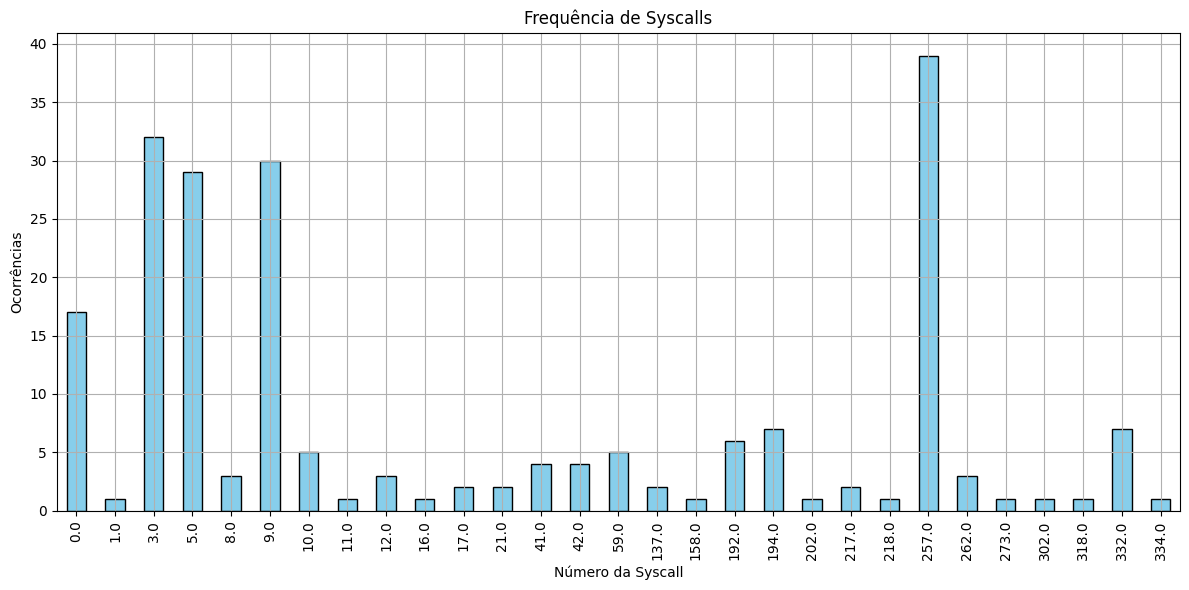

In [10]:
syscall_counts = df_final["syscall"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
syscall_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Frequência de Syscalls")
plt.xlabel("Número da Syscall")
plt.ylabel("Ocorrências")
plt.grid(True)
plt.tight_layout()
plt.show()
